In [5]:
import geopandas as gpd
import matplotlib.pyplot as plt
import xarray as xr
import rioxarray

# Load local CMIP6 data (Historical & Future SSP2-4.5)
ds_hist = xr.open_dataset(
    '../data/tas_Amon_MRI-ESM2-0_historical_r1i1p1f1_gn_185001-201412.nc'
)['tas']
ds_ssp = xr.open_dataset(
    "../data/tas_Amon_MRI-ESM2-0_ssp245_r1i1p1f1_gn_201501-210012.nc"
)['tas']

# Slice and concatenate timelines
tas_full = xr.concat(
    [
        ds_hist.sel(time=slice("1981", "2014")),
        ds_ssp.sel(time=slice("2015", "2100")),
    ],
    dim="time",
)

In [ ]:
# Convert Kelvin to Celsius and crop to India box
tas_india = tas_full.sel(lat=slice(6, 37), lon=slice(68, 98)) - 273.15
tas_india.attrs["units"] = "degC" 

# Baseline climatology (1981-2010)
baseline = (
    tas_india.sel(time=slice("1981", "2010"))
    .groupby("time.year")
    .mean("time")
    .mean("year")
)  # dims: (lat, lon)

# Future period (2041-2070) — spatially resolved ---
future_period = (
    tas_india.sel(time=slice("2041", "2070"))
    .groupby("time.year")
    .mean(dim="time")
)  # dims: (year, lat, lon)

# Per-pixel anomaly: each cell's future temp minus that SAME cell's own baseline
anomaly = future_period - baseline
anomaly.attrs["units"] = "degC"
mean_anomaly_map = anomaly.mean(dim="year")  # Spatial 2D grid of warming
mean_anomaly_map.attrs["units"] = "degC"

print("baseline dims:", baseline.dims, "| shape:", baseline.shape)
print("mean_anomaly_map dims:", mean_anomaly_map.dims, "| units:", mean_anomaly_map.attrs.get("units"))
print(f"India-wide mean warming (SSP2-4.5, 2041-2070 vs 1981-2010): {float(mean_anomaly_map.mean()):.2f} °C")


baseline dims: ('lat', 'lon') | shape: (28, 27)
mean_anomaly_map dims: ('lat', 'lon') | units: degC
India-wide mean warming (SSP2-4.5, 2041-2070 vs 1981-2010): 1.58 °C


In [7]:
# Check your coordinate names first
print(mean_anomaly_map.dims)

# If your dimensions are ('lat', 'lon'):
mean_anomaly_map = mean_anomaly_map.rio.set_spatial_dims(
    x_dim="lon",
    y_dim="lat"
)

# Tell rioxarray that lon/lat are WGS84
mean_anomaly_map = mean_anomaly_map.rio.write_crs("EPSG:4326")

('lat', 'lon')


In [8]:
districts_url = "https://raw.githubusercontent.com/HariKumarValluru/India-Map-with-States-and-Districts-GeoJson/master/districts.geojson"

districts = gpd.read_file(districts_url)

print(districts.head())
print(districts.crs)
print(len(districts))


  dt_code                  district st_code    year                st_nm  \
0     639  North and Middle Andaman      35  2011_c  Andaman and Nicobar   
1     640             South Andaman      35  2011_c  Andaman and Nicobar   
2     638                  Nicobars      35  2011_c  Andaman and Nicobar   
3     542                Srikakulam      37  2011_c       Andhra Pradesh   
4     543              Vizianagaram      37  2011_c       Andhra Pradesh   

                                            geometry  
0  MULTIPOLYGON (((92.75575 12.17525, 92.75538 12...  
1  MULTIPOLYGON (((92.52055 10.89783, 92.55898 10...  
2  MULTIPOLYGON (((93.89962 7.08159, 93.89832 7.0...  
3  POLYGON ((83.64488 18.10658, 83.62348 18.11275...  
4  POLYGON ((83.75648 18.91056, 83.7747 18.89823,...  
EPSG:4326
732


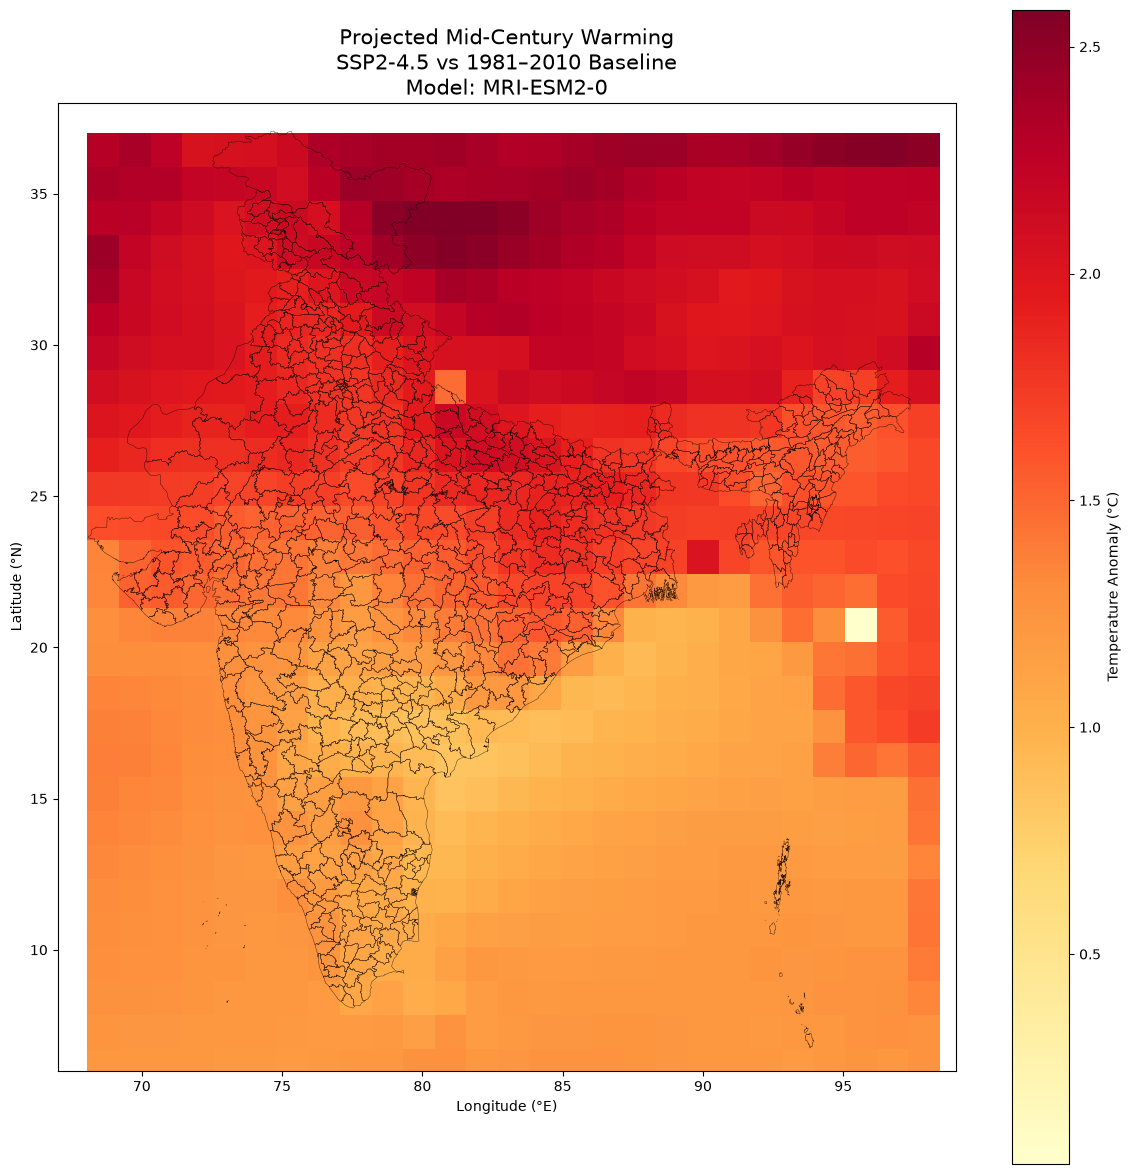

In [ ]:
fig, ax = plt.subplots(figsize=(12, 12))

mean_anomaly_map.plot(
    ax=ax,
    cmap="YlOrRd",
    cbar_kwargs={
        "label": "Temperature Anomaly (°C)"
    }
)

# Overlay district boundaries
districts.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.3,
    alpha=0.8,
    zorder=10
)

# Set India extent
ax.set_xlim(67, 99)
ax.set_ylim(6, 38)

ax.set_title(
    "Projected Mid-Century Warming\n"
    "SSP2-4.5 vs 1981–2010 Baseline\n"
    "Model: MRI-ESM2-0",
    fontsize=15
)

ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")



plt.tight_layout()

plt.savefig(
    "../outputs/india_warming_districts.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
